Loading PyTorch Models...
  Model 15d loaded.
  Model 60d loaded.
  Model 90d loaded.

  STARTING EVALUATION PIPELINE (Neural Baseline vs Neuro-Symbolic Hybrid)

 Extraction and Inference on Window: 7 days...
    Window 7d completed: Processed 722 samples.

 Extraction and Inference on Window: 14 days...
    Window 14d completed: Processed 603 samples.

 Extraction and Inference on Window: 30 days...
    Window 30d completed: Processed 393 samples.

 Extraction and Inference on Window: 60 days...
    Window 60d completed: Processed 182 samples.

 Extraction and Inference on Window: 90 days...
    Window 90d completed: Processed 21 samples.

 Generating Results Charts and Metrics for CIKM Paper...

--- NEURAL BASELINE (PURE M_60) ---
              precision    recall  f1-score   support

       GREEN      0.986     0.755     0.855      1098
      YELLOW      0.746     0.966     0.842       527
         RED      0.528     0.709     0.605       296

    accuracy                          0

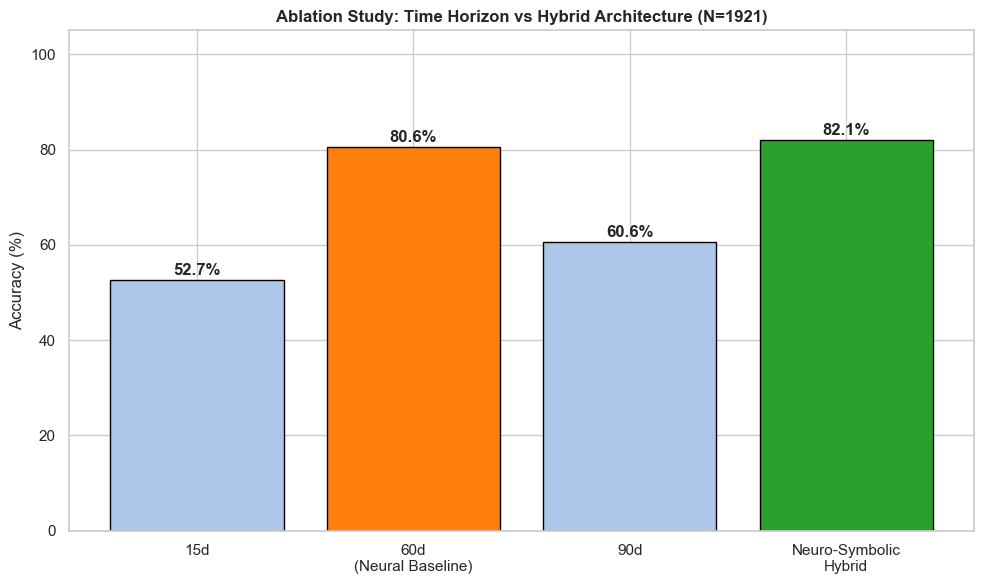

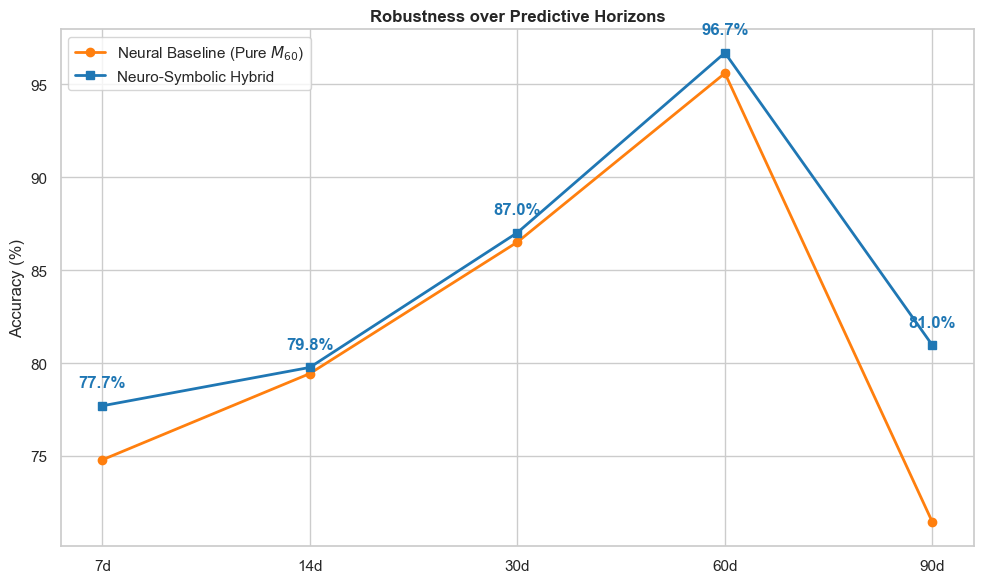

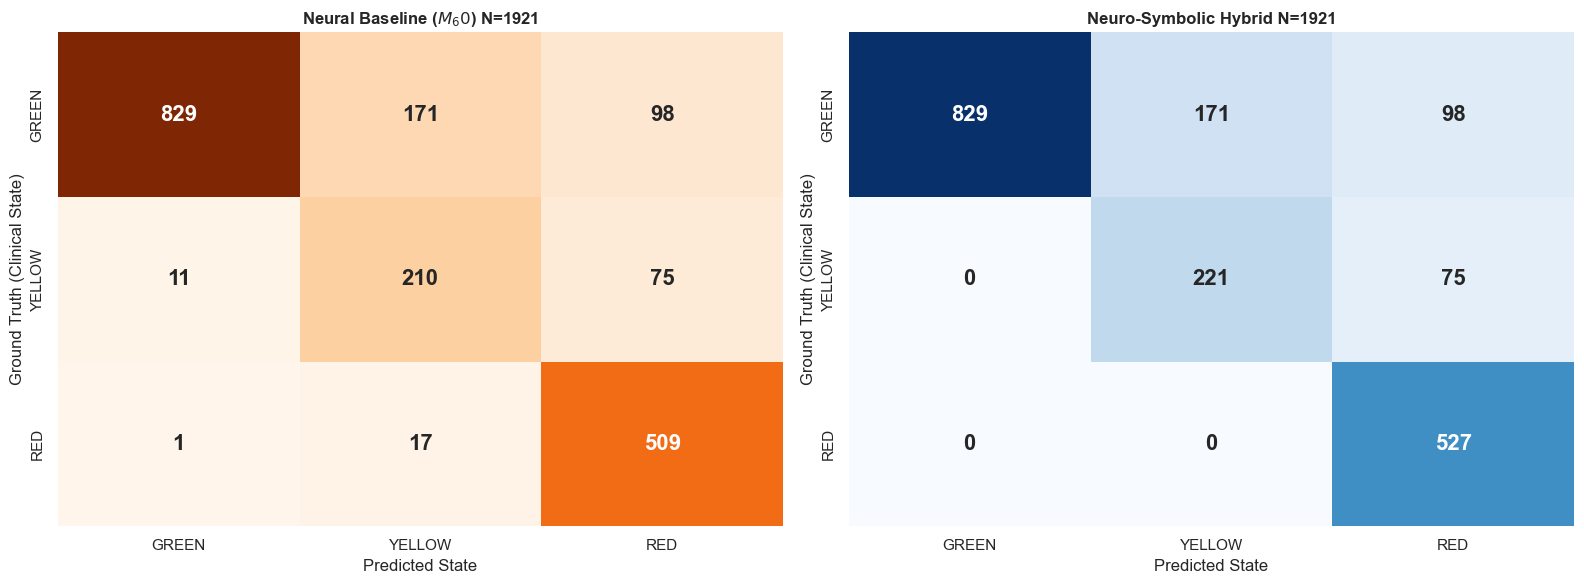

In [1]:
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. BASE CONFIGURATIONS
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABELS_ORD = ["GREEN", "YELLOW", "RED"]
INT_TO_TARGET = {0: "RED", 1: "YELLOW", 2: "GREEN"}
STATE_ID = {"extremely_low": 0, "low": 1, "normal": 2, "high": 3, "extremely_high": 4}
NUM_STATES = 5

multi_window_results = {}
ablation_real_stats = {15: [], 60: [], 90: []}


# ============================================================
# 2. NEURAL ARCHITECTURE
# ============================================================
def map_glucose_to_state(g):
    if g < 60: return "extremely_low"
    if g <= 75: return "low"
    if g <= 160: return "normal"
    if g <= 240: return "high"
    return "extremely_high"


def transform_glucose_risk(g):
    g_clipped = np.clip(g, 20, 600)
    return 1.509 * (np.log(g_clipped) ** 1.084 - 5.381)


def build_compressed_features_v2(run_list):
    if not run_list: return np.zeros((1, 18), dtype=np.float32)
    states = np.array([STATE_ID.get(s, 2) for s, _, _ in run_list], dtype=int)
    durs = np.array([d for _, d, _ in run_list], dtype=float)
    gs = np.array([g for _, _, g in run_list], dtype=float)

    state_oh = np.eye(NUM_STATES)[states]
    prev_oh = np.eye(NUM_STATES)[np.roll(states, 1)];
    prev_oh[0] = state_oh[0]
    dur_norm = np.clip(durs / 240.0, 0, 1)
    log_dur = np.log1p(durs)
    g_delta = gs - np.roll(gs, 1);
    g_delta[0] = 0
    roc = np.nan_to_num(np.where(durs > 0, g_delta / durs, 0))
    risk = transform_glucose_risk(gs)
    load = (gs - 100) * (durs / 60.0)
    zsc = (gs - 140) / 50.0
    roll_risk = np.convolve(risk, np.ones(5) / 5, mode='same') if len(risk) >= 5 else risk
    feats = np.column_stack([state_oh, prev_oh, dur_norm, log_dur, zsc, g_delta, roc, risk, roll_risk, load])
    return np.nan_to_num(feats).astype(np.float32)


class AttentionBlock(nn.Module):
    def __init__(self, h_dim):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(h_dim, h_dim // 2), nn.Tanh(), nn.Linear(h_dim // 2, 1))

    def forward(self, x, lens):
        sc = self.att(x)
        mask = torch.zeros_like(sc, dtype=torch.bool)
        for i, l in enumerate(lens): mask[i, :l, :] = 1
        return torch.sum(torch.softmax(sc.masked_fill(~mask, -1e9), dim=1) * x, dim=1)


class LSTMAttentionClassifier(nn.Module):
    def __init__(self, input_dim=18, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.attn = AttentionBlock(hidden_dim * 2)
        self.ln = nn.LayerNorm(hidden_dim * 2)
        self.fc = nn.Sequential(nn.Linear(hidden_dim * 2, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, 3))

    def forward(self, x, l):
        packed = nn.utils.rnn.pack_padded_sequence(x, l.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        unpacked, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.ln(self.attn(unpacked, l)))


# ============================================================
# 3. CLINICAL LOGIC AND MODEL INFERENCE
# ============================================================
def get_objective_clinical_target(g):
    if len(g) == 0: return "GREEN"
    TBR = np.mean(g < 70) * 100
    TIR = np.mean((g >= 70) & (g <= 180)) * 100
    TAR = np.mean(g > 180) * 100
    GV = np.std(g)
    if (TBR > 10) or (TAR > 40) or (GV > 70) or (TIR < 55): return "RED"
    if (TBR > 4) or (TAR > 25) or (GV > 50) or (TIR < 70): return "YELLOW"
    return "GREEN"


def apply_smart_safety_guardrail(g, ai_class_int):
    if len(g) == 0: return INT_TO_TARGET[ai_class_int], False

    TBR = np.mean(g < 70) * 100
    TIR = np.mean((g >= 70) & (g <= 180)) * 100
    TAR = np.mean(g > 180) * 100
    GV = np.std(g)

    # --- LEVEL 1: EMERGENCY (RED) ---
    if (TBR > 10) or (TAR > 40) or (GV > 70) or (TIR < 55):
        return "RED", True

    # --- LEVEL 2: CAUTION (YELLOW) ---
    is_borderline = (TBR > 4) or (TAR > 25) or (GV > 50) or (TIR < 70)
    if is_borderline and ai_class_int == 2:
        return "YELLOW", True

    # --- LEVEL 3: AI TRUST ---
    return INT_TO_TARGET[ai_class_int], False


def convert_raw_to_runlist(raw_values):
    if len(raw_values) == 0: return []
    res, cs, cv = [], map_glucose_to_state(raw_values[0]), [raw_values[0]]
    for g in raw_values[1:]:
        s = map_glucose_to_state(g)
        if s == cs:
            cv.append(g)
        else:
            res.append((cs, len(cv) * 5, np.mean(cv)))
            cs, cv = s, [g]
    res.append((cs, len(cv) * 5, np.mean(cv)))
    return res


def process_file_to_runlist(file_path):
    df = None
    if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
        try:
            df = pd.read_excel(file_path, sheet_name='CGM')
            if 'Local Time' in df.columns:
                df['Local Time'] = pd.to_datetime(df['Local Time'])
                df = df.sort_values(by='Local Time', ascending=True)
        except Exception as e:
            print(f"  Errore Excel {file_path}: {e}")
            return [], []
    else:
        for sep in [';', ',', '\t']:
            try:
                test_df = pd.read_csv(file_path, sep=sep, nrows=5)
                if len(test_df.columns) > 1:
                    df = pd.read_csv(file_path, sep=sep)
                    break
            except:
                continue
        if df is None:
            try:
                df = pd.read_csv(file_path, sep=None, engine='python')
            except:
                return [], []

    if df is None or df.empty: return [], []

    df.columns = [str(c).strip() for c in df.columns]
    possible_cols = ['Valore del glucosio (mg/dL)', 'Glucose Value (mg/dL)', 'Glucosio', 'sgv', 'glucose', 'valore',
                     'Value']
    col = next((c for c in possible_cols if c in df.columns), None)

    if col is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            col = numeric_cols[0]
        else:
            return [], []

    raw = pd.to_numeric(df[col], errors='coerce').dropna().values
    return convert_raw_to_runlist(raw), raw


def predict_all_models(models, run_list):
    indiv_preds = {}
    with torch.no_grad():
        for days, model in models.items():
            t_min, c_min, sub = days * 1440, 0, []
            for s, d, v in reversed(run_list):
                if c_min + d > t_min:
                    rem = t_min - c_min
                    if rem > 0: sub.insert(0, (s, int(rem), v))
                    break
                sub.insert(0, (s, d, v));
                c_min += d
            if not sub: continue
            feat = torch.tensor(build_compressed_features_v2(sub)).unsqueeze(0).to(DEVICE)
            logits = model(feat, torch.tensor([len(feat[0])]).to(DEVICE))
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            indiv_preds[days] = INT_TO_TARGET[np.argmax(probs)]
    return indiv_preds


def process_and_track(raw_g, run_l, models, stats_dict):
    if len(raw_g) < 10 or not run_l: return

    true_label = get_objective_clinical_target(raw_g)
    indiv_preds = predict_all_models(models, run_l)

    stats_dict["total"] += 1

    # Aggiornato a 15, 60, 90
    for d in [15, 60, 90]:
        if d in indiv_preds:
            hit = 1 if indiv_preds[d] == true_label else 0
            ablation_real_stats[d].append(hit)
            if hit: stats_dict[f"hits_{d}d"] += 1

    base_ai_60d = indiv_preds.get(60, "GREEN")
    base_ai_int = {"RED": 0, "YELLOW": 1, "GREEN": 2}[base_ai_60d]

    hybrid_label, is_override = apply_smart_safety_guardrail(raw_g, base_ai_int)

    if base_ai_60d == true_label: stats_dict["hits_60d_pure"] += 1
    if hybrid_label == true_label: stats_dict["hits_hybrid"] += 1
    if is_override: stats_dict["overrides"] += 1

    stats_dict["y_true"].append(true_label)
    stats_dict["y_ai_60"].append(base_ai_60d)
    stats_dict["y_hybrid"].append(hybrid_label)


# ============================================================
# 4. DATASET AND SLIDING WINDOW PIPELINE
# ============================================================
def run_full_pipeline(files_list, data_dir, models_dict, window_list):
    global multi_window_results

    print("\n" + "=" * 80)
    print("  STARTING EVALUATION PIPELINE (Neural Baseline vs Neuro-Symbolic Hybrid)")
    print("=" * 80)

    global_metrics = {"total_files": 0, "total_points": 0, "total_days": 0.0,
                      "classes": {"GREEN": 0, "YELLOW": 0, "RED": 0}}

    for win_days in window_list:
        print(f"\n Extraction and Inference on Window: {win_days} days...")
        current_stats = {"total": 0, "hits_15d": 0, "hits_60d": 0, "hits_90d": 0,
                         "hits_60d_pure": 0, "hits_hybrid": 0, "overrides": 0, "y_true": [], "y_ai_60": [],
                         "y_hybrid": []}

        for file_name in files_list:
            path = os.path.join(data_dir, file_name)
            if not os.path.exists(path): continue
            try:
                rl, rg = process_file_to_runlist(path)
                if len(rl) == 0: continue

                total_days = sum(d for _, d, _ in rl) / 1440

                if win_days == window_list[0]:
                    global_metrics["total_files"] += 1
                    global_metrics["total_points"] += len(rg)
                    global_metrics["total_days"] += total_days
                    global_metrics["classes"][get_objective_clinical_target(rg)] += 1

                process_and_track(rg, rl, models_dict, current_stats)
                if total_days >= win_days:
                    num_windows = int(total_days - win_days) + 1
                    samples_per_day = len(rg) / total_days
                    for w in range(num_windows):
                        s_idx = int(w * samples_per_day)
                        e_idx = int((w + win_days) * samples_per_day)
                        raw_s = rg[s_idx:e_idx]
                        process_and_track(raw_s, convert_raw_to_runlist(raw_s), models_dict, current_stats)
            except Exception as e:
                pass

        multi_window_results[win_days] = current_stats
        print(f"    Window {win_days}d completed: Processed {current_stats['total']} samples.")


# ============================================================
# 5. GENERATING RESULTS CHARTS AND MATRICES
# ============================================================
def generate_final_results_and_charts():
    print("\n Generating Results Charts and Metrics for CIKM Paper...")

    accs = []
    for d in [15, 60, 90]:
        if len(ablation_real_stats[d]) > 0:
            accs.append(np.mean(ablation_real_stats[d]) * 100)
        else:
            accs.append(0)

    tot_samples = sum(s['total'] for s in multi_window_results.values())
    tot_60d = sum(s['hits_60d_pure'] for s in multi_window_results.values())
    tot_hyb = sum(s['hits_hybrid'] for s in multi_window_results.values())

    acc_hyb = (tot_hyb / tot_samples) * 100 if tot_samples > 0 else 0

    # GRAFICO 1: ABLATION STUDY (Senza il 30d, nomenclatura accademica)
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    models = ['15d', '60d\n(Neural Baseline)', '90d', 'Neuro-Symbolic\nHybrid']
    final_accs = accs + [acc_hyb]
    bars = plt.bar(models, final_accs, color=['#aec7e8', '#ff7f0e', '#aec7e8', '#2ca02c'], edgecolor='black')
    for bar in bars: plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{bar.get_height():.1f}%',
                              ha='center', fontweight='bold')
    plt.title(f'Ablation Study: Time Horizon vs Hybrid Architecture (N={tot_samples})', fontweight='bold')
    plt.ylim(0, 105);
    plt.ylabel('Accuracy (%)');
    plt.tight_layout()
    plt.savefig('results_1_model_comparison_cikm.png', dpi=300)

    windows = list(multi_window_results.keys())
    win_labels = [f"{w}d" for w in windows]

    list_acc_60d, list_acc_hyb, all_y_true, all_y_hybrid, all_y_ai_60 = [], [], [], [], []

    for w in windows:
        s = multi_window_results[w]
        tot = s['total'] if s['total'] > 0 else 1
        a_60, a_hyb = (s['hits_60d_pure'] / tot) * 100, (s['hits_hybrid'] / tot) * 100
        list_acc_60d.append(a_60);
        list_acc_hyb.append(a_hyb)
        all_y_true.extend(s['y_true'])
        all_y_hybrid.extend(s['y_hybrid'])
        all_y_ai_60.extend(s['y_ai_60'])

    # GRAFICO 2: LINEE ACCURATEZZA
    plt.figure(figsize=(10, 6))
    plt.plot(win_labels, list_acc_60d, marker='o', linewidth=2, color='#ff7f0e',
             label='Neural Baseline (Pure $M_{60}$)')
    plt.plot(win_labels, list_acc_hyb, marker='s', linewidth=2, color='#1f77b4', label='Neuro-Symbolic Hybrid')
    for i, txt in enumerate(list_acc_hyb): plt.annotate(f"{txt:.1f}%", (win_labels[i], list_acc_hyb[i] + 1),
                                                        ha='center', fontweight='bold', color='#1f77b4')
    plt.title('Robustness over Predictive Horizons', fontweight='bold')
    plt.ylabel('Accuracy (%)');
    plt.legend();
    plt.tight_layout()
    plt.savefig('results_2_accuracy_lines_cikm.png', dpi=300)

    # GRAFICO 3: MATRICI DI CONFUSIONE
    cm_pure = confusion_matrix(all_y_true, all_y_ai_60, labels=LABELS_ORD)
    cm_hybrid = confusion_matrix(all_y_true, all_y_hybrid, labels=LABELS_ORD)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(pd.DataFrame(cm_pure, index=LABELS_ORD, columns=LABELS_ORD),
                annot=True, fmt='d', cmap='Oranges', annot_kws={"size": 16, "weight": "bold"}, cbar=False, ax=axes[0])
    axes[0].set_title(f'Neural Baseline ($M_{60}$) N={tot_samples}', fontweight='bold')
    axes[0].set_ylabel('Ground Truth (Clinical State)')
    axes[0].set_xlabel('Predicted State')

    sns.heatmap(pd.DataFrame(cm_hybrid, index=LABELS_ORD, columns=LABELS_ORD),
                annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16, "weight": "bold"}, cbar=False, ax=axes[1])
    axes[1].set_title(f'Neuro-Symbolic Hybrid N={tot_samples}', fontweight='bold')
    axes[1].set_ylabel('Ground Truth (Clinical State)')
    axes[1].set_xlabel('Predicted State')

    plt.tight_layout()
    plt.savefig('results_3_matrices_comparison_cikm.png', dpi=300)

    # ============================================================
    # STAMPA REPORT METRICHE (F1-SCORE)
    # ============================================================
    print("\n--- NEURAL BASELINE (PURE M_60) ---")
    print(classification_report(all_y_true, all_y_ai_60, target_names=["GREEN", "YELLOW", "RED"], digits=3))

    print("\n--- NEURO-SYMBOLIC HYBRID (M_60 + GUARDRAIL) ---")
    print(classification_report(all_y_true, all_y_hybrid, target_names=["GREEN", "YELLOW", "RED"], digits=3))

    print("=" * 85 + "\n")


# ============================================================
# 6. MAIN EXECUTION
# ============================================================
if __name__ == "__main__":
    MODELS_DIR, DATA_DIR = "../data/models_opt/", "../data/csv/"

    real_files = [
        "patient_1/glucoseLevel.csv", "patient_1/glucoseLevel2.csv", "patient_1/glucoseLevel3.csv",
        "patient_1/Clarity_Esporta_patient_1_2025-12-19_133917.csv",
        "patient_1/Clarity_Esporta_patient_1__2025-12-19_133933.csv",
        "patient_1/Clarity_Esporta__patient_1_2025-12-19_133927.csv",
        "patient_1/Clarity_Esporta_patient_1_2025-12-19_134020.csv",
        "patient_1/glucose_level_giallo.csv",

        "patient_2_to_11/dataset_online_10_pazienti.csv",

        "patient_12/Clarity_Esporta_patient_12_2026-03-24_205813.csv",
        "patient_12/Clarity_Esporta_patient_122026-03-24_210102.csv",
        "patient_12/Clarity_Esporta_patient_12_2026-03-24_210508.csv",



        "patient_15/export_3.csv",
        "patient_15/export_4.csv",
        "patient_15/export_5.csv",
        "patient_15/export_6.csv",
        "patient_15/export_7.csv",
        "patient_15/export_2.csv",
        "patient_15/export_1.csv",
        "patient_14/dexcome_esterno.csv"

    ]

    print("Loading PyTorch Models...")
    models_dict = {}
    # Rimosso il 30d anche dal caricamento
    for d in [15, 60, 90]:
        p = os.path.join(MODELS_DIR, f"model_{d}d.pth")
        if os.path.exists(p):
            m = LSTMAttentionClassifier().to(DEVICE)
            m.load_state_dict(torch.load(p, map_location=DEVICE))
            m.eval();
            models_dict[d] = m;
            print(f"  Model {d}d loaded.")

    if models_dict:
        run_full_pipeline(real_files, DATA_DIR, models_dict, window_list=[7, 14, 30, 60, 90])
        generate_final_results_and_charts()